In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm # pip install -U statsmodels patsy 
import statsmodels.formula.api as smf
import patsy as pt 

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/finches.csv")

In [3]:
df.head()

,island,winglength,taillength,beakwidth,beakheight,lowerbeaklength,upperbeaklength,tarsuslength,middletoelength
0,santacruz,63.5,40.0,9.0,11.0,9.0,16.0,20.0,18.5
1,santacruz,69.5,41.0,9.0,12.0,8.5,16.0,21.2,19.5
2,santacruz,70.0,44.0,9.2,12.0,8.5,16.0,21.0,18.6
3,santacruz,70.0,43.5,9.2,11.2,8.5,16.2,20.5,19.0
4,santacruz,70.5,42.0,9.5,12.0,8.5,16.5,22.0,19.2


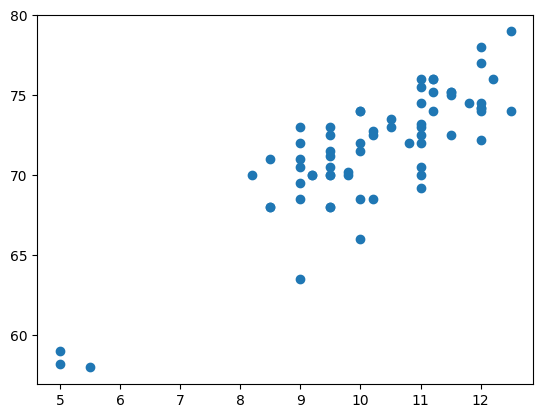

In [5]:
plt.scatter(df["beakwidth"], df["winglength"]);

In [6]:
y, X = pt.dmatrices("winglength ~ beakwidth", data = df) # design matricess

In [17]:
model = smf.ols("winglength ~ island + beakwidth", data = df)
fit = model.fit()

In [18]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winglength   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     68.81
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           5.32e-20
Time:                        13:30:28   Log-Likelihood:                -141.84
No. Observations:                  68   AIC:                             291.7
Df Residuals:                      64   BIC:                             300.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 48.6534      1.632     29.821      0.000      45.394      51.913
island[T.sancristobal]    -1.6948      0.578     -2.932      0.005      -2.849      -0.540
island[T.santacruz]       -1.5701      0.660     -2.379      0.020      -2.889      -0.251
beakwidth                  2.3520      0.165     14.284      0.000       2.023       2.681
==============================================================================
Omnibus:                        3.560   Durbin-Watson:                   1.897
Prob(Omnibus):                  0.169   Jarque-Bera (JB):                2.913
Skew:                          -0.390   Prob(JB):                        0.233
Kurtosis:                       2.351   Cond. No.                         69.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

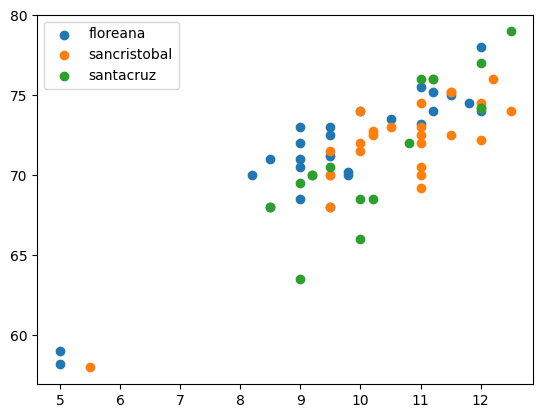

In [24]:
for name, gdf in df.groupby(["island"]):
    plt.scatter(gdf["beakwidth"], gdf["winglength"], label = name[0]);
plt.legend();

In [28]:
xnew = np.array([5, 12])
ndf = pd.DataFrame.from_dict({"beakwidth": xnew, 
                              "island": ["floreana", "floreana"]})
ndf["yhat"] = fit.predict(ndf)
ndf

,beakwidth,island,yhat
0,5,floreana,60.413616
1,12,floreana,76.877965
